## Interrupt

An interrupt is a programmatic pause in the execution of a LangGraph workflow. When triggered, it:

- Suspends execution at the current node.

- Persists the graph state using the configured checkpointer.

- Waits indefinitely for an external signal to resume.

Interrupts in LangGraph provide a powerful **mechanism to pause graph execution at runtime, enabling dynamic, human-in-the-loop interactions or external system integrations**. This feature is essential for workflows that require asynchronous input or decision-making before proceeding.

Exercise-1

    Implement a Human Approval Workflow Using LangGraph Interrupts

Objective:

    Design and implement a LangGraph-based workflow that simulates a human-in-the-loop approval system for critical actions (e.g., financial transactions). The workflow should pause execution to request human approval before proceeding with the action.

Problem Statement:

    You are tasked with building a simple approval system using LangGraph where:
    
    A user initiates a request to perform a sensitive action (e.g., "Transfer $500").
    
    The system pauses execution and prompts for human approval using the interrupt() function.
    
    Based on the human's response (True for approval, False for rejection), the workflow either: 
    
    Proceeds to execute the action and marks the status as "approved", or
    
    Cancels the action and marks the status as "rejected".

Requirements:

    Define a TypedDict-based state to hold:
    
    action_details: A string describing the action.
    
    status: A string indicating the current status ("pending", "approved", or "rejected").

Implement the following nodes:

    approval_node: Uses interrupt() to pause and request approval.
    
    proceed_node: Updates the status to "approved".
    
    cancel_node: Updates the status to "rejected".
    
    Use a MemorySaver checkpointer for state persistence.
    
    Use a thread_id to manage execution state and resume the graph after interruption.
    
    Demonstrate both the initial invocation (which pauses) and the resumption with a decision.

Expected Output:

    On the first invocation, the graph should return an __interrupt__ payload with the approval question and action details.
    
    Upon resuming with Command(resume=True), the graph should return {"status": "approved"}.
    
    Upon resuming with Command(resume=False), the graph should return {"status": "rejected"}.



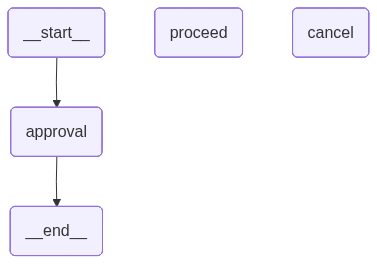

In [6]:
from typing import Literal, Optional, TypedDict
from typing_extensions import Annotated
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt

# --- Define State ---
class ApprovalState(TypedDict):
    action_details: str
    status: Annotated[Optional[Literal["pending", "approved", "rejected"]], "replace"]

# --- Nodes ---
def approval_node(state: ApprovalState) -> Command:
    decision = interrupt({
        "question": "Approve this action?",
        "details": state["action_details"],
    })
    # Route dynamically, not statically
    if decision:
        return Command(goto="proceed")
    else:
        return Command(goto="cancel")

def proceed_node(state: ApprovalState) -> ApprovalState:
    print("Proceeding with approval...")
    return {"status": "approved"}

def cancel_node(state: ApprovalState) -> ApprovalState:
    print(" Action rejected.")
    return {"status": "rejected"}

# --- Build Graph ---
builder = StateGraph(ApprovalState)
builder.add_node("approval", approval_node)
builder.add_node("proceed", proceed_node)
builder.add_node("cancel", cancel_node)

# Only the START and terminal edges
builder.add_edge(START, "approval")
builder.add_edge("proceed", END)
builder.add_edge("cancel", END)

# --- Compile ---
checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph


In [8]:
# --- Run ---
config = {"configurable": {"thread_id": "approval-123"}}

initial = graph.invoke(
    {"action_details": "Transfer $500", "status": "pending"},
    config=config,
)
print("\n--- Interrupt Triggered ---")
print(initial["__interrupt__"])



--- Interrupt Triggered ---
[Interrupt(value={'question': 'Approve this action?', 'details': 'Transfer $500'}, id='ef60ce5f3a0c738afe620480d9c8a1b3')]


In [9]:
# Resume
resumed = graph.invoke(Command(resume=False), config=config)
print("\n--- Final Result ---")
print(resumed["status"])


 Action rejected.

--- Final Result ---
rejected


In [11]:
# Resume
resumed = graph.invoke(Command(resume=True), config=config)
print("\n--- Final Result ---")
print(resumed["status"])


--- Final Result ---
rejected


In [13]:
# resumed = graph.invoke({}, config=config)
# print("\n--- Final Result ---")
# print(resumed)


## Human Input Driven 

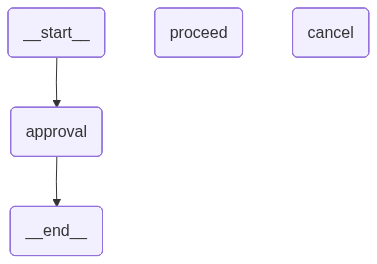

In [12]:
from typing import Literal, Optional, TypedDict
from typing_extensions import Annotated
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
# --- Define State Schema ---

class ApprovalState(TypedDict):
    action_details: str
    status: Annotated[Optional[Literal["pending", "approved", "rejected"]], "replace"]

# --- Nodes ---
def approval_node(state: ApprovalState) -> Command:
    """Ask for approval and pause for user input."""
    decision = interrupt({
        "question": "Approve this action?",
        "details": state["action_details"],
        "options": ["Approve", "Reject"]
    })
    # Route dynamically based on user input at resume
    if decision.lower() == "approve":
        return Command(goto="proceed")
    else:
        return Command(goto="cancel")
        
def proceed_node(state: ApprovalState) -> ApprovalState:
    print("Proceeding with approval...")
    return {"status": "approved"}
    
def cancel_node(state: ApprovalState) -> ApprovalState:
    print("Action rejected.")
    return {"status": "rejected"}
    
# --- Build Graph ---
builder = StateGraph(ApprovalState)
builder.add_node("approval", approval_node)
builder.add_node("proceed", proceed_node)
builder.add_node("cancel", cancel_node)
builder.add_edge(START, "approval")
builder.add_edge("proceed", END)
builder.add_edge("cancel", END)
# --- Compile ---

checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [13]:

# --- Run Graph (Interactive Flow) ---
config = {"configurable": {"thread_id": "approval-123"}}
# Step 1: Trigger interrupt
initial = graph.invoke(
    {"action_details": "Transfer $500", "status": "pending"},
    config=config,
)
interrupts = initial.get("__interrupt__")
interrupts

[Interrupt(value={'question': 'Approve this action?', 'details': 'Transfer $500', 'options': ['Approve', 'Reject']}, id='5efe8e15715b749e4de606b61ac55381')]

In [14]:
if interrupts:
    question = interrupts[0].value["question"]
    details = interrupts[0].value["details"]
    options = interrupts[0].value.get("options", [])
    print("\n--- Approval Request ---")
    print(f"Action: {details}")
    print(f"{question}")
    print(f"Options: {options}")
    # Take user decision
    user_input = input("Enter your decision (Approve/Reject): ").strip()
    # Step 2: Resume with user input
    
    resumed = graph.invoke(Command(resume=user_input), config=config)
    print("\n--- Final Decision ---")
    print(f"User chose: {user_input}")
    print(f"Final Status: {resumed['status']}")
else:
    print("No interrupt found process completed.")



--- Approval Request ---
Action: Transfer $500
Approve this action?
Options: ['Approve', 'Reject']


Enter your decision (Approve/Reject):  Reject


Action rejected.

--- Final Decision ---
User chose: Reject
Final Status: rejected


## LLM With Interrupt

In [15]:
# -----------------------------
# Imports
# -----------------------------
from typing import TypedDict, List
from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END
import os


from typing import Literal, Optional, TypedDict
from typing_extensions import Annotated
from langchain_aws import BedrockLLM
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
import json

# ---------------------------
# AWS Bedrock LLM Setup
# ---------------------------
#llm = ChatBedrockConverse(model_id="amazon.nova-lite-v1:0", region_name="us-east-1", temperature=0.5, max_tokens=50)
llm = ChatBedrockConverse(model_id="cohere.command-r-plus-v1:0", region_name="us-east-1", temperature=0.5, max_tokens=100)


class ApprovalState(TypedDict):
    action_details: str
    llm_decision: Optional[str]
    llm_confidence: Optional[float]
    status: Annotated[Optional[Literal["pending", "approved", "rejected"]], "replace"]
    #The "replace" metadata might define how this property is handled during updates in a specific API or database interaction.

def llm_validate_node(state: ApprovalState) -> Command | ApprovalState:
    prompt = f"""
    You are an autonomous financial approval system.
    Review this transaction and decide whether to approve or reject it.
    
    Transaction: {state['action_details']}
    
    Respond ONLY in JSON:
    {{
        "decision": "approve" or "reject",
        "confidence": number between 0 and 1
    }}
    """
    response = llm.invoke(prompt)
    try:
        parsed = json.loads(response)
        decision = parsed.get("decision", "reject").lower()
        confidence = float(parsed.get("confidence", 0.0))
    except Exception:
        decision, confidence = "reject", 0.0
        
    print(f"\n LLM Decision: {decision.upper()} (confidence={confidence:.2f})")
    state["llm_decision"] = decision
    state["llm_confidence"] = confidence
    
    if confidence >= 0.7:
        next_node = "proceed" if decision == "approve" else "cancel"
        return Command(goto=next_node)
    else:
        # Pause and ask human
        decision = interrupt({
            "question": f"LLM is uncertain. Approve this transaction?",
            "details": state["action_details"],
            "llm_decision": decision,
            "confidence": confidence
        })
        # decision will be True or False
        if decision:
            return Command(goto="proceed")
        else:
            return Command(goto="cancel")
            
def proceed_node(state: ApprovalState) -> ApprovalState:
    print(" Transaction Approved.")
    state["status"] = "approved"
    return state
    
def cancel_node(state: ApprovalState) -> ApprovalState:
    print("Transaction Rejected.")
    state["status"] = "rejected"
    return state
    
# --- Build Graph ---
builder = StateGraph(ApprovalState)
builder.add_node("validate", llm_validate_node)
builder.add_node("proceed", proceed_node)
builder.add_node("cancel", cancel_node)
builder.add_edge(START, "validate")
builder.add_edge("proceed", END)
builder.add_edge("cancel", END)

checkpointer = MemorySaver()

graph = builder.compile(checkpointer=checkpointer)
config = {"configurable": {"thread_id": "txn-001"}}
# --- Run ---
initial_state = {"action_details": "Transfer $500 to Account ID 98765", "status": "pending"}
result = graph.invoke(initial_state, config=config)
interrupts = result.get("__interrupt__")
interrupts


 LLM Decision: REJECT (confidence=0.00)


[Interrupt(value={'question': 'LLM is uncertain. Approve this transaction?', 'details': 'Transfer $500 to Account ID 98765', 'llm_decision': 'reject', 'confidence': 0.0}, id='924e2c51eb87923df035833a57e3436f')]

In [16]:
if interrupts:
    info = interrupts[0].value
    print("\nHuman Approval Required:")
    print(f"Transaction: {info['details']}")
    print(f"LLM Decision: {info['llm_decision']} (Confidence: {info['confidence']})")
    user_input = input("Enter your decision (Approve/Reject): ").strip().lower()
    
    
    resumed = graph.invoke(
        Command(resume=(user_input == "approve")),
        config=config,
    )
    print("\n--- Final Result ---")
    print(f"User chose: {user_input.capitalize()}")
    print(f"Final Status: {resumed['status']}")
else:
    print("\n--- Final Result ---")
    print(f"Autonomous Status: {result['status']}")



Human Approval Required:
Transaction: Transfer $500 to Account ID 98765
LLM Decision: reject (Confidence: 0.0)


Enter your decision (Approve/Reject):  Approve



 LLM Decision: REJECT (confidence=0.00)
 Transaction Approved.

--- Final Result ---
User chose: Approve
Final Status: approved
